In [1]:
%load_ext rpy2.ipython

In [2]:
%%R

library(DESeq2)
library(dplyr)
library(tidyverse)
library(ggplot2)
library(RColorBrewer)
library(pheatmap)
library(tximport)
library(ggrepel)
library(GenomicFeatures)
library(AnnotationHub)
library(ensembldb)
library(stringr)
library(biomaRt)
library("pheatmap")
library(EnhancedVolcano)
library("org.Mm.eg.db")
library("gprofiler2")
library("ChIPpeakAnno")
library('TxDb.Mmusculus.UCSC.mm10.ensGene')
library("ChIPseeker")
library(clusterProfiler)
library(stringr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()        masks matrixStats::count()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖ dplyr::filter()       masks stats::filter()
✖ dplyr::first()        masks S4Vectors::first()
✖ dplyr::lag()          masks stats::lag()
✖ ggplot2::Position()   masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()       masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()       masks S4Vectors::rename()
✖ lubridate::second()  

Loading required package: S4Vectors
Loading required package: stats4
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Attaching package: ‘S4Vectors’

The following object is masked from ‘package:utils’:

    findMatches

The following objects are masked from ‘package:base’:

    expand.grid, I, unname

Loading required package: IRanges
Loading required package: GenomicRanges
Loading required package: GenomeInfoDb
Loading requ

### Get pseudobulk data from open-source scRNA-seq data of Old and Control samples

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scanpy as sc
from adpbulk import ADPBulk

In [4]:
df = sc.read_h5ad('/tank/projects/kashuk_sirt6_hic/old_rnaseq/BrainAgingSpatialAtlas_snRNAseq.h5ad')

In [5]:
adpb = ADPBulk(df, ["cell_type", "age", "donor_id"], use_raw=True)

In [6]:
pseudobulk_matrix = adpb.fit_transform()

Aggregating Samples: 100%|██████████| 104/104 [00:05<00:00, 17.45it/s]


In [7]:
sample_meta = adpb.get_meta()
sample_meta.head(5)

,age,cell_type,donor_id,SampleName
0,4wk,T cell,10X_MsBrainAgingSpatialDonor_5,age.4wk-cell_type.T cell-donor_id.10X_MsBrainA...
1,4wk,T cell,10X_MsBrainAgingSpatialDonor_6,age.4wk-cell_type.T cell-donor_id.10X_MsBrainA...
2,4wk,astrocyte,10X_MsBrainAgingSpatialDonor_5,age.4wk-cell_type.astrocyte-donor_id.10X_MsBra...
3,4wk,astrocyte,10X_MsBrainAgingSpatialDonor_6,age.4wk-cell_type.astrocyte-donor_id.10X_MsBra...
4,4wk,cell,10X_MsBrainAgingSpatialDonor_5,age.4wk-cell_type.cell-donor_id.10X_MsBrainAgi...


In [8]:
pseudobulk_matrix

,ENSMUSG00000051951,ENSMUSG00000025900,ENSMUSG00000025902,ENSMUSG00000033845,ENSMUSG00000025903,ENSMUSG00000033813,ENSMUSG00000002459,ENSMUSG00000033793,ENSMUSG00000025905,ENSMUSG00000033774,...,ENSMUSG00000072844,ENSMUSG00000093806,ENSMUSG00000053211,ENSMUSG00000056673,ENSMUSG00000069049,ENSMUSG00000068457,ENSMUSG00000069045,ENSMUSG00000069044,ENSMUSG00000000103,ENSMUSG00000096256
age.4wk-cell_type.T cell-donor_id.10X_MsBrainAgingSpatialDonor_5,12.0,0.0,0.0,0.0,4.0,5.0,0.0,7.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
age.4wk-cell_type.T cell-donor_id.10X_MsBrainAgingSpatialDonor_6,2.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
age.4wk-cell_type.astrocyte-donor_id.10X_MsBrainAgingSpatialDonor_5,1869.0,6.0,1.0,235.0,484.0,727.0,24140.0,1127.0,37.0,0.0,...,17.0,20.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0
age.4wk-cell_type.astrocyte-donor_id.10X_MsBrainAgingSpatialDonor_6,1973.0,4.0,2.0,244.0,575.0,807.0,25663.0,1309.0,47.0,1.0,...,10.0,27.0,0.0,0.0,0.0,1.0,0.0,5.0,0.0,3.0
age.4wk-cell_type.cell-donor_id.10X_MsBrainAgingSpatialDonor_5,194.0,0.0,0.0,12.0,38.0,45.0,1284.0,65.0,4.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
age.4wk-cell_type.cell-donor_id.10X_MsBrainAgingSpatialDonor_6,186.0,3.0,0.0,14.0,38.0,55.0,1591.0,85.0,4.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
age.4wk-cell_type.endothelial cell-donor_id.10X_MsBrainAgingSpatialDonor_5,295.0,18.0,54.0,13.0,24.0,45.0,85.0,51.0,3.0,0.0,...,1.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
age.4wk-cell_type.endothelial cell-donor_id.10X_MsBrainAgingSpatialDonor_6,199.0,17.0,80.0,14.0,56.0,58.0,120.0,68.0,7.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
age.4wk-cell_type.inhibitory interneuron-donor_id.10X_MsBrainAgingSpatialDonor_5,63390.0,46.0,2.0,645.0,779.0,1951.0,2321.0,3230.0,123.0,0.0,...,22.0,33.0,1.0,0.0,0.0,2.0,0.0,15.0,0.0,33.0
age.4wk-cell_type.inhibitory interneuron-donor_id.10X_MsBrainAgingSpatialDonor_6,61143.0,30.0,3.0,563.0,768.0,1860.0,2120.0,3283.0,124.0,6.0,...,14.0,21.0,2.0,0.0,1.0,0.0,0.0,10.0,0.0,42.0


### Subsetting neurons

In [9]:
neuronal_types = ["inhibitory interneuron", "medium spiny neuron", "neuron"]

neuron_rows = pseudobulk_matrix[pseudobulk_matrix.index.str.contains("|".join(neuronal_types))]

### Subsetting by age: Control - 4 weeks, Old - 90 weeks

In [10]:
df_4wk = neuron_rows[neuron_rows.index.str.startswith("age.4wk")]
df_90wk = neuron_rows[neuron_rows.index.str.startswith("age.90wk")]

df_4wk.index = df_4wk.index.str.replace(r'cell_type\..*?-donor_id', 'donor_id', regex=True)
df_90wk.index = df_90wk.index.str.replace(r'cell_type\..*?-donor_id', 'donor_id', regex=True)

df_4wk_grouped = df_4wk.groupby(df_4wk.index).sum()
df_90wk_grouped = df_90wk.groupby(df_90wk.index).sum()

df_4wk_grouped.index = [f"4wk.sample{i+1}" for i in range(len(df_4wk_grouped))]
df_90wk_grouped.index = [f"90wk.sample{i+1}" for i in range(len(df_90wk_grouped))]

df_4wk_grouped_transposed = df_4wk_grouped.T
df_90wk_grouped_transposed = df_90wk_grouped.T

df_merged = df_4wk_grouped_transposed.merge(df_90wk_grouped_transposed, left_index=True, right_index=True, how="inner")  

df_merged.head(5)

#df_merged.to_csv('/tank/projects/kashuk_sirt6_hic/old_rnaseq/pseudobulk_expression_raw_counts_4wk_90wk.csv')

,4wk.sample1,4wk.sample2,90wk.sample1,90wk.sample2
ENSMUSG00000051951,342166.0,356709.0,299867.0,283446.0
ENSMUSG00000025900,107.0,124.0,85.0,116.0
ENSMUSG00000025902,9.0,20.0,2.0,5.0
ENSMUSG00000033845,4462.0,4362.0,3413.0,3380.0
ENSMUSG00000025903,4897.0,5211.0,4193.0,4687.0


## DESeq2 differential analysis

### Annotation

In [11]:
%%R

ah <- AnnotationHub()

mm10_ens <- query(ah, c("Mus musculus", "EnsDb"))
mm10_ens

mm10_ens <- mm10_ens[["AH109655"]]

genedb <- genes(mm10_ens, return.type = "data.frame")

head(genedb, 3)
genedb2 <- dplyr::select(genedb, gene_id, symbol)

txdb <- transcripts(mm10_ens, return.type = "data.frame")
head(txdb)
txdb2 <- dplyr::select(txdb, tx_id, gene_id)

tx2gene <- right_join(txdb2, genedb2, by='gene_id')
head(tx2gene)


               tx_id            gene_id  symbol
1 ENSMUST00000082387 ENSMUSG00000064336   mt-Tf
2 ENSMUST00000179436 ENSMUSG00000095742        
3 ENSMUST00000082388 ENSMUSG00000064337 mt-Rnr1
4 ENSMUST00000082389 ENSMUSG00000064338   mt-Tv
5 ENSMUST00000082390 ENSMUSG00000064339 mt-Rnr2
6 ENSMUST00000082391 ENSMUSG00000064340  mt-Tl1


snapshotDate(): 2024-10-28
loading from cache


### Read pseudobulk data for Old/Control samples

In [12]:
%%R

data <- read.csv("/tank/projects/kashuk_sirt6_hic/old_rnaseq/pseudobulk_expression_raw_counts_4wk_90wk.csv", sep=',', row.names = 1)
genotype <- factor(c(rep("Control", 2), rep("Old",2)))

meta <- data.frame(genotype, row.names = colnames(data))
meta

              genotype
X4wk.sample1   Control
X4wk.sample2   Control
X90wk.sample1      Old
X90wk.sample2      Old


### Normalization

In [13]:
%%R

dds <- DESeqDataSetFromMatrix(countData = data, colData = meta, design = ~ genotype)

dds <- estimateSizeFactors(dds)
sizeFactors(dds)

colSums(counts(dds))

normalized_counts <- counts(dds, normalized=TRUE)

converting counts to integer mode


### Quality control

In [14]:
%%R

rld <- rlog(dds, blind=TRUE)

#### PCA

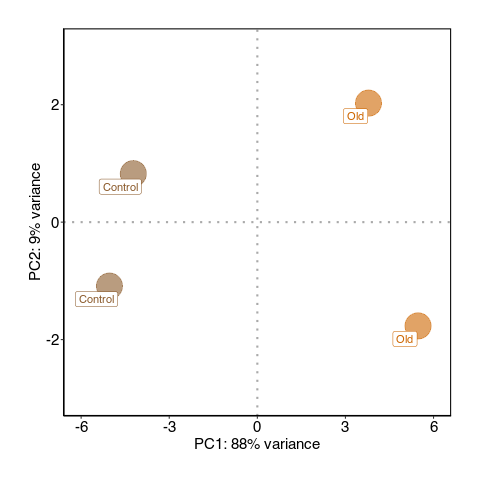

In [19]:
%%R

intgroup <- "genotype"
ntop <- 300

rv <- rowVars(assay(rld))

select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, length(rv)))]

pca <- prcomp(t(assay(rld)[select, ]))

percentVar <- pca$sdev^2/sum(pca$sdev^2)

intgroup.df <- as.data.frame(colData(rld)[, intgroup, drop = FALSE])
group <- if (length(intgroup) > 1) {
  factor(apply(intgroup.df, 1, paste, collapse = " : "))
} else {
  colData(rld)[[intgroup]]
}

d1 <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], intgroup.df, name = colnames(rld))

d1$genotype <- c(rep('Control', 2), rep('Old', 2))

ggplot(d1, aes(x=PC1, y=PC2, colour = genotype)) + 
  geom_point(size=12, alpha = 0.6) +
  ylim(-3, 3) + xlim(-6, 6) +
  xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
  ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) +
  geom_hline(yintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  geom_vline(xintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  theme_classic() +
  geom_label_repel(aes(label = genotype),
                   box.padding   = 0.3, 
                   point.padding = 0.1,
                   segment.color = 'grey50',
                   force         = 0.1,
                   segment.size  = 0.2,
                   max.overlaps = 100,
                   angle = 40
  ) +
  theme(axis.text.y   = element_text(size=15,colour = "black"),
        axis.text.x   = element_text(size=15,colour = "black"),
        axis.title.y  = element_text(size=15,colour = "black"),
        axis.title.x  = element_text(size=15,colour = "black"),
        axis.line = element_line(colour = "black"),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        legend.position = "none",
        aspect.ratio = 4/4,
        plot.margin = unit(c(1,1,1,1), "cm")
  ) +
  scale_colour_manual(values = c('tan4', 'darkorange3'))


#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/PCA_old_control.pdf', dpi = 1200)

#### Correlation heatmap

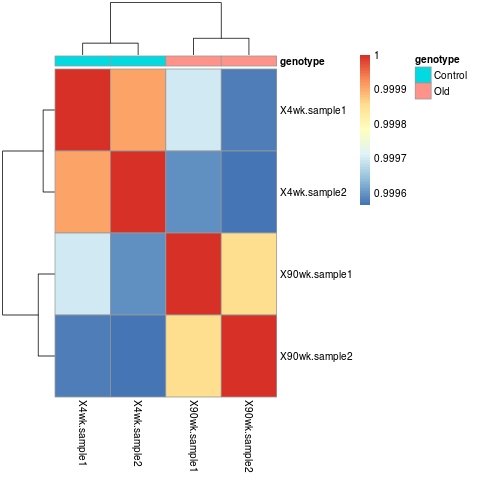

In [20]:
%%R

rld_mat <- assay(rld)

rld_cor <- cor(rld_mat)
pheatmap(rld_cor, annotation = meta)


### Statistical testing

using pre-existing size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895


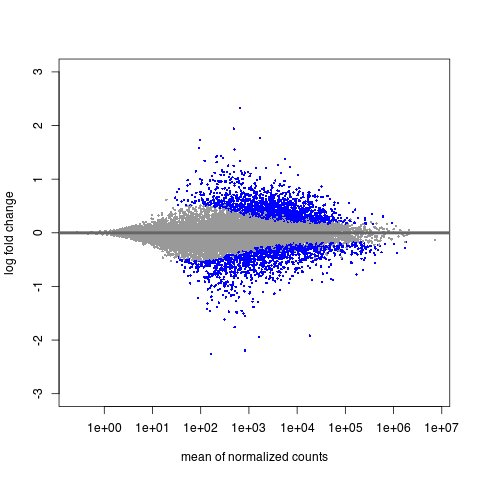

In [21]:
%%R

dds_analysis <- DESeq(dds)

plotDispEsts(dds_analysis)

contrast <- c("genotype", "Old", "Control")

res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)

res <- lfcShrink(dds_analysis, contrast=contrast, res=res_unshrunken, type='normal')

plotMA(res, ylim=c(-3,3))

In [22]:
%%R

summary(res)

padj.cutoff <- 0.05
lfc.cutoff <- 0.58

res_tb <- res %>% data.frame() %>% rownames_to_column(var="gene") %>% as_tibble()
sig <- res_tb %>%dplyr::filter(padj < padj.cutoff & abs(log2FoldChange) >= lfc.cutoff)

res.df <- as.data.frame(res)

res.df$gene_id <- rownames(res.df)
res.df.an <- left_join(res.df, genedb2, by='gene_id')

sig_an <- left_join(sig, genedb2, by=c('gene'='gene_id'))

head(sig_an)


#write.csv(sig_an, '/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Old_Control.csv')
#write.csv(res.df.an, '/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Old_Control.csv')


out of 20742 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 1779, 8.6%
LFC < 0 (down)     : 1347, 6.5%
outliers [1]       : 0, 0%
low counts [2]     : 4823, 23%
(mean count < 29)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results

# A tibble: 6 × 8
  gene             baseMean log2FoldChange  lfcSE  stat   pvalue     padj symbol
  <chr>               <dbl>          <dbl>  <dbl> <dbl>    <dbl>    <dbl> <chr> 
1 ENSMUSG00000033…    2758.         -0.673 0.0972 -6.93 4.31e-12 3.75e-10 St18  
2 ENSMUSG00000025…    3296.          0.932 0.0930 10.0  1.16e-23 6.36e-21 Crisp…
3 ENSMUSG00000042…     874.         -0.763 0.170  -4.50 6.93e- 6 1.27e- 4 Tfap2d
4 ENSMUSG00000089…     166.         -0.987 0.202  -4.90 9.47e- 7 2.21e- 5 49304…
5 ENSMUSG00000038…     704.         -1.46  0.153  -9.48 2.44e-21 9.26e-19 Aox4  
6 ENSMUSG00000025…    1853.         -0.740 0.139  -5.32 1.01e- 7 3.22e- 6 Pth2r 


### Tximport for shSIRT6/shCtrl samples

In [23]:
%%R

samples <- list.files(path = "/tank/projects/kashuk_rnaseq/rnaseq/", full.names = T) 
samples

files <- file.path(samples, "quant.sf")
files

names(files) <- str_replace(samples, "/tank/projects/kashuk_rnaseq/rnaseq", "")
files


txi <- tximport(files, 
                type="salmon", 
                tx2gene=tx2gene[,c("tx_id", "gene_id")],
                countsFromAbundance="lengthScaledTPM")

attributes(txi)

data <- data.frame(round(txi$counts))

reading in files with read_tsv
1 2 3 4 5 
transcripts missing from tx2gene: 5640
summarizing abundance
summarizing counts
summarizing length


In [24]:
%%R

genotype <- factor(c(rep("shCtrl", 3), rep("shSIRT6",2)))

meta <- data.frame(genotype, row.names = colnames(data))
meta

                  genotype
X..shScrambled_R1   shCtrl
X..shScrambled_R2   shCtrl
X..shScrambled_R3   shCtrl
X..shSIRT6_R2      shSIRT6
X..shSIRT6_R3      shSIRT6


### Normalization

In [25]:
%%R

dds <- DESeqDataSetFromMatrix(countData = data, colData = meta, design = ~ genotype)

dds <- estimateSizeFactors(dds)
sizeFactors(dds)

colSums(counts(dds))

normalized_counts <- counts(dds, normalized=TRUE)

converting counts to integer mode


### Quality control

In [26]:
%%R

rld <- rlog(dds, blind=TRUE)

#### PCA

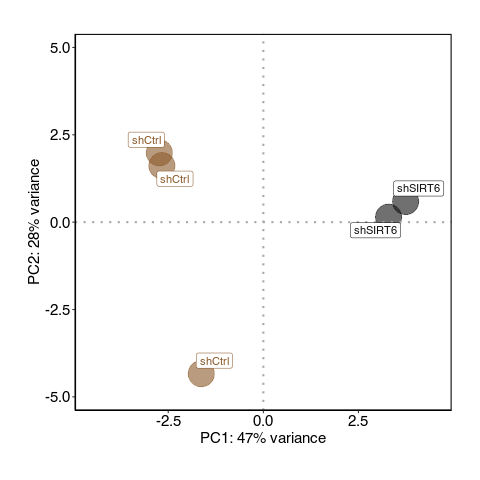

In [29]:
%%R

intgroup <- "genotype"
ntop <- 500

rv <- rowVars(assay(rld))

select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, length(rv)))]

pca <- prcomp(t(assay(rld)[select, ]))

percentVar <- pca$sdev^2/sum(pca$sdev^2)

intgroup.df <- as.data.frame(colData(rld)[, intgroup, drop = FALSE])
group <- if (length(intgroup) > 1) {
  factor(apply(intgroup.df, 1, paste, collapse = " : "))
} else {
  colData(rld)[[intgroup]]
}

d1 <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], intgroup.df, name = colnames(rld))

d1$genotype <- c(rep("shCtrl", 3), rep("shSIRT6",2))

ggplot(d1, aes(x=PC1, y=PC2, colour = genotype)) + 
  geom_point(size=12, alpha = 0.6) +
  ylim(-4.9, 4.9) + xlim(-4.5, 4.5) +
  xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
  ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) +
  geom_hline(yintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  geom_vline(xintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  theme_classic() +
  geom_label_repel(aes(label = genotype),
                   box.padding   = 0.3, 
                   point.padding = 0.1,
                   segment.color = 'grey50',
                   force         = 0.1,
                   segment.size  = 0.2,
                   max.overlaps = 100,
                   angle = 40
  ) +
  theme(axis.text.y   = element_text(size=15,colour = "black"),
        axis.text.x   = element_text(size=15,colour = "black"),
        axis.title.y  = element_text(size=15,colour = "black"),
        axis.title.x  = element_text(size=15,colour = "black"),
        axis.line = element_line(colour = "black"),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        legend.position = "none",
        aspect.ratio = 4/4,
        plot.margin = unit(c(1,1,1,1), "cm")
  ) +
  scale_colour_manual(values = c('tan4', 'gray7'))

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/PCA_shSIRT6_shCtrl.pdf', dpi = 1200)

#### Correlation heatmap

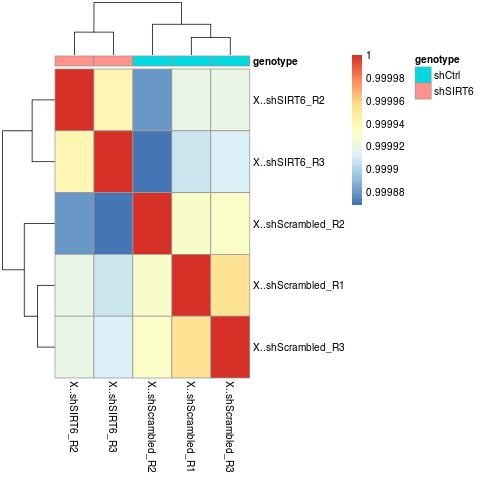

In [30]:
%%R

rld_mat <- assay(rld)

rld_cor <- cor(rld_mat)
pheatmap(rld_cor, annotation = meta)

### Statistical testing

using pre-existing size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895


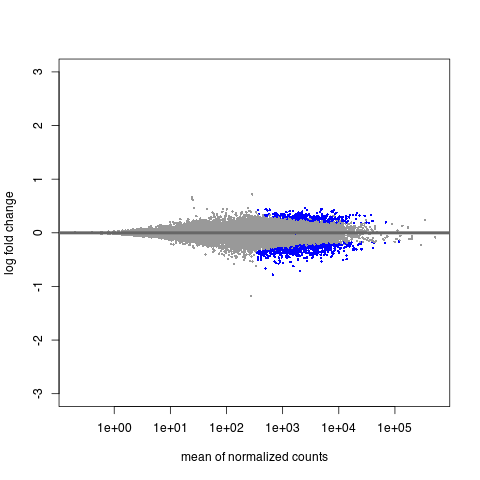

In [31]:
%%R

dds_analysis <- DESeq(dds)

plotDispEsts(dds_analysis)

contrast <- c("genotype", "shSIRT6", "shCtrl")

res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)

res <- lfcShrink(dds_analysis, contrast=contrast, res=res_unshrunken, type='normal')

plotMA(res, ylim=c(-3,3))

In [32]:
%%R

summary(res)

padj.cutoff <- 0.05

res_tb <- res %>% data.frame() %>% rownames_to_column(var="gene") %>% as_tibble()
sig <- res_tb %>%dplyr::filter(padj < padj.cutoff)
res.df <- as.data.frame(res)

res.df$gene_id <- rownames(res.df)
res.df.an <- left_join(res.df, genedb2, by='gene_id')

sig_an <- left_join(sig, genedb2, by=c('gene'='gene_id'))

head(sig_an)


#write.csv(sig_an, '/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_shSIRT6_shCtrl.csv')
#write.csv(res.df.an, '/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_shSIRT6_shCtrl.csv')


out of 25433 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 331, 1.3%
LFC < 0 (down)     : 562, 2.2%
outliers [1]       : 1, 0.0039%
low counts [2]     : 15786, 62%
(mean count < 354)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results

# A tibble: 6 × 8
  gene               baseMean log2FoldChange  lfcSE  stat  pvalue    padj symbol
  <chr>                 <dbl>          <dbl>  <dbl> <dbl>   <dbl>   <dbl> <chr> 
1 ENSMUSG00000000168    1649.         -0.255 0.0836 -3.05 2.33e-3 0.0319  Dlat  
2 ENSMUSG00000000184   34521.          0.187 0.0565  3.31 9.27e-4 0.0174  Ccnd2 
3 ENSMUSG00000000278    4002.          0.305 0.0825  3.70 2.14e-4 0.00678 Scpep1
4 ENSMUSG00000000567    7701.          0.241 0.0643  3.74 1.83e-4 0.00615 Sox9  
5 ENSMUSG00000000605    4859.         -0.237 0.0737 -3.22 1.30e-3 0.0218  Clcn4 
6 ENSMUSG00000000881    1979.         -0.250 0.0803 -3.11 1.85e-3 0.0274  Dlg3  


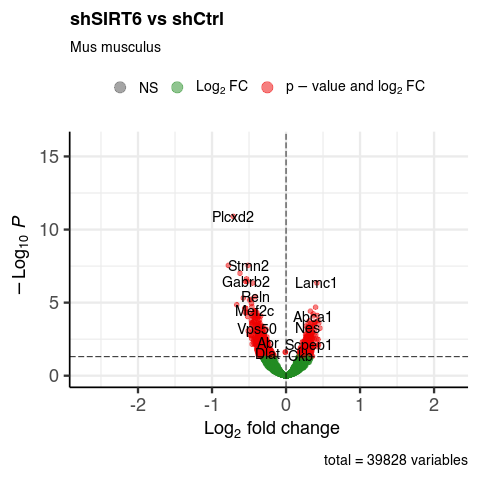

In [33]:
%%R

EnhancedVolcano(res.df.an,
                lab = res.df.an$symbol, 
                x = 'log2FoldChange',
                y = 'padj', 
                title = 'shSIRT6 vs shCtrl',
                subtitle = 'Mus musculus',
                pCutoff = 0.05, 
                FCcutoff = 0)

### Tximport for Step1, Step2, Control samples

In [34]:
%%R

samples <- list.files(path = "/tank/projects/kashuk_sirt6_hic/ad/rnaseq/salmon_quants", full.names = T) 
samples

files <- file.path(samples, "quant.sf")
files

names(files) <- str_replace(samples, "/tank/projects/kashuk_sirt6_hic/ad/rnaseq/salmon_quants", "")
files


txi <- tximport(files, 
                type="salmon", 
                tx2gene=tx2gene[,c("tx_id", "gene_id")],
                countsFromAbundance="lengthScaledTPM")

attributes(txi)

data <- data.frame(round(txi$counts))

reading in files with read_tsv
1 2 3 4 5 6 
transcripts missing from tx2gene: 5640
summarizing abundance
summarizing counts
summarizing length


In [35]:
%%R

genotype <- factor(c(rep("Control", 2), rep("Step1",2), rep("Step2",2)))

meta <- data.frame(genotype, row.names = colnames(data))
meta

            genotype
X.baseline1  Control
X.baseline2  Control
X.stage1_1     Step1
X.stage1_2     Step1
X.stage2_1     Step2
X.stage2_2     Step2


### Normalization

In [36]:
%%R

dds <- DESeqDataSetFromMatrix(countData = data, colData = meta, design = ~ genotype)

dds <- estimateSizeFactors(dds)
sizeFactors(dds)

colSums(counts(dds))

normalized_counts <- counts(dds, normalized=TRUE)

converting counts to integer mode


### Quality control

In [37]:
%%R

rld <- rlog(dds, blind=TRUE)

#### PCA

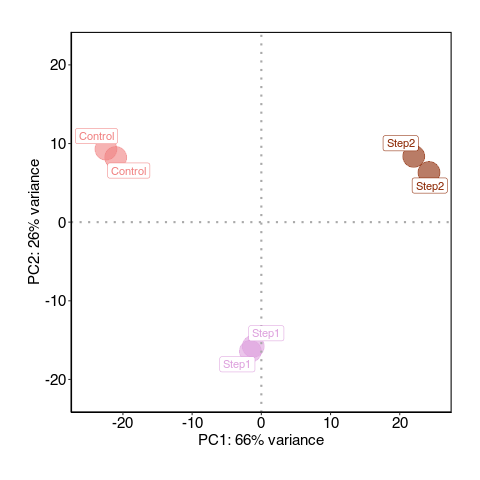

In [40]:
%%R

intgroup <- "genotype"
ntop <- 300

rv <- rowVars(assay(rld))

select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, length(rv)))]

pca <- prcomp(t(assay(rld)[select, ]))

percentVar <- pca$sdev^2/sum(pca$sdev^2)

intgroup.df <- as.data.frame(colData(rld)[, intgroup, drop = FALSE])
group <- if (length(intgroup) > 1) {
  factor(apply(intgroup.df, 1, paste, collapse = " : "))
} else {
  colData(rld)[[intgroup]]
}

d1 <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], intgroup.df, name = colnames(rld))

d1$genotype <- c(rep('Control', 2), rep('Step1', 2), rep('Step2', 2))

ggplot(d1, aes(x=PC1, y=PC2, colour = genotype)) + 
  geom_point(size=10, alpha = 0.6) +
  ylim(-22, 22) + xlim(-25, 25) +
  xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
  ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) +
  geom_hline(yintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  geom_vline(xintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  theme_classic() +
  geom_label_repel(aes(label = genotype),
                   box.padding   = 0.3, 
                   point.padding = 0.1,
                   segment.color = 'grey50',
                   force         = 0.1,
                   segment.size  = 0.2,
                   max.overlaps = 100,
                   angle = 40
  ) +
  theme(axis.text.y   = element_text(size=15,colour = "black"),
        axis.text.x   = element_text(size=15,colour = "black"),
        axis.title.y  = element_text(size=15,colour = "black"),
        axis.title.x  = element_text(size=15,colour = "black"),
        axis.line = element_line(colour = "black"),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        legend.position = "none",
        aspect.ratio = 4/4,
        plot.margin = unit(c(1,1,1,1), "cm")
  ) +
  scale_colour_manual(values = c('lightcoral', 'plum', 'orangered4'))

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/PCA_Step1_Step2_Control.pdf', dpi = 1200)

#### Correlation heatmap

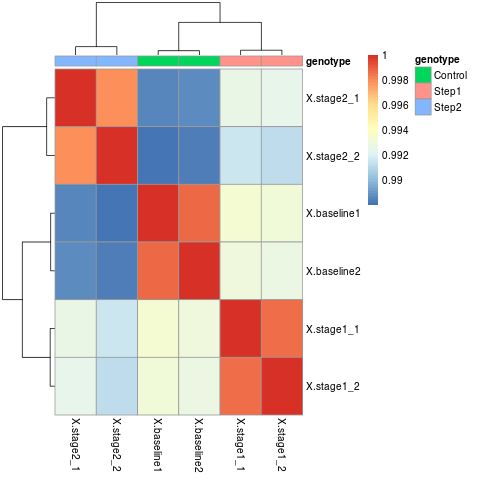

In [41]:
%%R

rld_mat <- assay(rld)

rld_cor <- cor(rld_mat)
pheatmap(rld_cor, annotation = meta)

### Statistical testing

In [42]:
### Step1 vs Control

using pre-existing size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895


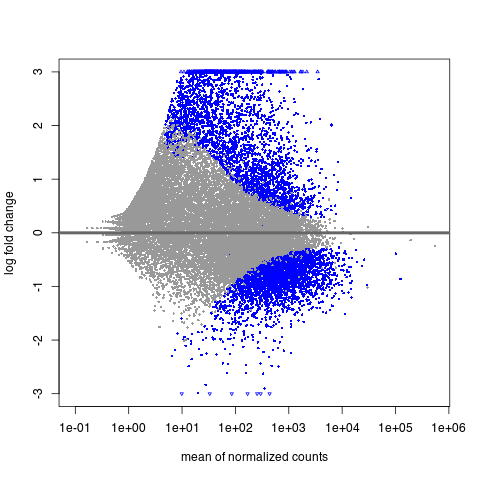

In [43]:
%%R

dds_analysis <- DESeq(dds)

plotDispEsts(dds_analysis)

contrast <- c("genotype", "Step1", "Control")

res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)

res <- lfcShrink(dds_analysis, contrast=contrast, res=res_unshrunken, type='normal')

plotMA(res, ylim=c(-3,3))

In [44]:
%%R

summary(res)

padj.cutoff <- 0.05
lfc.cutoff <- 0.58

res_tb <- res %>% data.frame() %>% rownames_to_column(var="gene") %>% as_tibble()
sig <- res_tb %>%dplyr::filter(padj < padj.cutoff & abs(log2FoldChange) >= lfc.cutoff)

res.df <- as.data.frame(res)

res.df$gene_id <- rownames(res.df)
res.df.an <- left_join(res.df, genedb2, by='gene_id')

sig_an <- left_join(sig, genedb2, by=c('gene'='gene_id'))

head(sig_an)


#write.csv(sig_an, '/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Step1_Control.csv')
#write.csv(res.df.an, '/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step1_Control.csv')


out of 28247 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 3208, 11%
LFC < 0 (down)     : 2878, 10%
outliers [1]       : 0, 0%
low counts [2]     : 8573, 30%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results

# A tibble: 6 × 8
  gene               baseMean log2FoldChange lfcSE  stat   pvalue    padj symbol
  <chr>                 <dbl>          <dbl> <dbl> <dbl>    <dbl>   <dbl> <chr> 
1 ENSMUSG00000000028    168.           1.25  0.316  3.96  7.40e-5 5.26e-4 Cdc45 
2 ENSMUSG00000000031     43.0          1.98  0.636  3.20  1.39e-3 6.77e-3 H19   
3 ENSMUSG00000000037    194.           1.75  0.340  5.15  2.63e-7 3.37e-6 Scml2 
4 ENSMUSG00000000056    374.          -0.859 0.212 -4.06  4.93e-5 3.69e-4 Narf  
5 ENSMUSG00000000085    765.          -0.641 0.168 -3.81  1.41e-4 9.27e-4 Scmh1 
6 ENSMUSG00000000093     26.8          2.83  0.672  3.90  9.61e-5 6.63e-4 Tbx2  


In [45]:
### Step2 vs Control

using pre-existing size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895


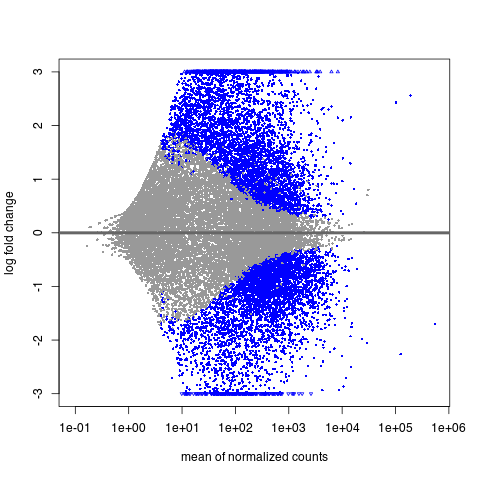

In [46]:
%%R

dds_analysis <- DESeq(dds)

plotDispEsts(dds_analysis)

contrast <- c("genotype", "Step2", "Control")

res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)

res <- lfcShrink(dds_analysis, contrast=contrast, res=res_unshrunken, type='normal')

plotMA(res, ylim=c(-3,3))

In [47]:
%%R

summary(res)

padj.cutoff <- 0.05
lfc.cutoff <- 0.58

res_tb <- res %>% data.frame() %>% rownames_to_column(var="gene") %>% as_tibble()
sig <- res_tb %>%dplyr::filter(padj < padj.cutoff & abs(log2FoldChange) >= lfc.cutoff)

res.df <- as.data.frame(res)

res.df$gene_id <- rownames(res.df)
res.df.an <- left_join(res.df, genedb2, by='gene_id')

sig_an <- left_join(sig, genedb2, by=c('gene'='gene_id'))

head(sig_an)


#write.csv(sig_an, '/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Step2_Control.csv')
#write.csv(res.df.an, '/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step2_Control.csv')


out of 28247 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 4886, 17%
LFC < 0 (down)     : 4231, 15%
outliers [1]       : 0, 0%
low counts [2]     : 9109, 32%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results

# A tibble: 6 × 8
  gene              baseMean log2FoldChange lfcSE  stat   pvalue     padj symbol
  <chr>                <dbl>          <dbl> <dbl> <dbl>    <dbl>    <dbl> <chr> 
1 ENSMUSG000000000…    168.           1.15  0.313  3.68 2.29e- 4 8.05e- 4 Cdc45 
2 ENSMUSG000000000…     43.0          3.34  0.626  5.02 5.06e- 7 2.88e- 6 H19   
3 ENSMUSG000000000…    194.           2.01  0.337  5.95 2.71e- 9 2.09e- 8 Scml2 
4 ENSMUSG000000000…    374.          -0.793 0.207 -3.83 1.28e- 4 4.77e- 4 Narf  
5 ENSMUSG000000000…    158.           1.50  0.313  4.78 1.78e- 6 9.23e- 6 Cav2  
6 ENSMUSG000000000…    765.          -1.30  0.168 -7.77 7.95e-15 1.12e-13 Scmh1 


### Vienn diagramm of DEGs

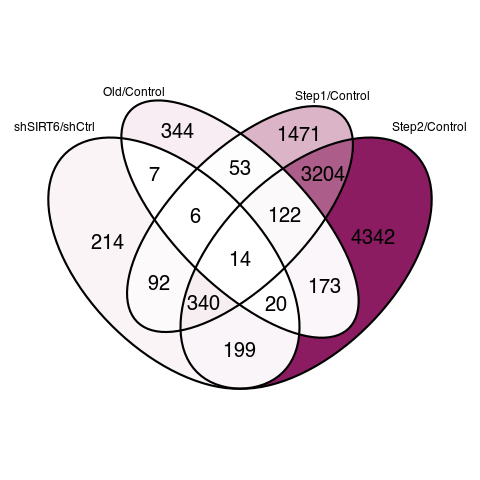

In [52]:
%%R

library(reshape2)
library(ggVennDiagram)

ko <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_shSIRT6_shCtrl.csv', row.names = 1)
s1 <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Step1_Control.csv', row.names = 1)
s2 <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Step2_Control.csv', row.names = 1)
old <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Old_Control.csv', row.names = 1)

gene_list <- list('shSIRT6/shCtrl' = ko$symbol, 'Old/Control' = old$symbol, 'Step1/Control' = s1$symbol, 'Step2/Control' = s2$symbol)

ggVennDiagram(gene_list, label = "count", label_alpha = 0, label_size =7) + 
  scale_fill_gradient(low = "white", high = "maroon4") + 
  theme(
    legend.position = "none", 
    text = element_text(size = 16), 
    strip.text = element_text(size = 25),  
    panel.grid = element_blank(),  # Remove grid
    plot.margin = margin(10, 10, 10, 10)
  ) +
  scale_x_continuous(expand = expansion(mult = 0.1))

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/Figure6_DEGs_diagram.pdf', dpi = 1200)

### REACTOME analysis

In [53]:
%%R

## Background

ko_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_shSIRT6_shCtrl.csv', row.names = 1)
s1_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step1_Control.csv', row.names = 1)
s2_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step2_Control.csv', row.names = 1)

## Only expressing genes as background
s1_all_filt <- s1_all %>% 
  dplyr::filter(baseMean > 0)
s2_all_filt <- s2_all %>% 
  dplyr::filter(baseMean > 0)
ko_all_filt <- ko_all %>% 
  dplyr::filter(baseMean > 0)

all_genes <- union(s1_all_filt$symbol, s2_all_filt$symbol)
all_genes <- unique(union(all_genes, ko_all_filt$symbol))

mart <- useEnsembl("ENSEMBL_MART_ENSEMBL", dataset="mmusculus_gene_ensembl", version=108)

back <- getBM(filters = "external_gene_name",
              attributes = c("entrezgene_id","ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
              values = all_genes, 
              mart = mart)


In [54]:
## Intersect DEGs 

In [55]:
%%R

ko <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_shSIRT6_shCtrl.csv', row.names = 1)
s1 <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Step1_Control.csv', row.names = 1)
s2 <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Step2_Control.csv', row.names = 1)

ko_s1 <- subset(ko, symbol %in% intersect(ko$symbol, s1$symbol))
ko_s2 <- subset(ko, symbol %in% intersect(ko$symbol, s2$symbol))

In [56]:
## Step1/Control & shSIRT6/shCtrl

In [57]:
%%R

library(ReactomePA)
library(enrichplot)

gene_data <- ko_s1

gene_annotations <- getBM(
  filters = "external_gene_name",
  attributes = c("entrezgene_id", "ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
  values = unique(gene_data$symbol), 
  mart = mart
)

annotated_data <- merge(
  gene_data, 
  gene_annotations, 
  by.x = 'symbol', 
  by.y = 'external_gene_name'
)

# Split into up/down regulated
upregulated <- subset(annotated_data, log2FoldChange > 0)
downregulated <- subset(annotated_data, log2FoldChange < 0)

# Pathway analysis 
pathway_analysis <- list(
  upregulated = enrichPathway(
    gene = upregulated$entrezgene_id,
    universe = as.character(back$entrezgene_id),
    organism = 'mouse',
    pvalueCutoff = 0.05,
    readable = TRUE
  ),
  
  downregulated = enrichPathway(
    gene = downregulated$entrezgene_id,
    universe = as.character(back$entrezgene_id),
    organism = 'mouse',
    pvalueCutoff = 0.05,
    readable = TRUE
  )
)


ReactomePA v1.50.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Qing-Yu He. ReactomePA: an R/Bioconductor package for
reactome pathway analysis and visualization. Molecular BioSystems.
2016, 12(2):477-479
enrichplot v1.26.6 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

S Xu, E Hu, Y Cai, Z Xie, X Luo, L Zhan, W Tang, Q Wang, B Liu, R Wang,
W Xie, T Wu, L Xie, G Yu. Using clusterProfiler to characterize
multiomics data. Nature Protocols. 2024, 19(11):3292-3320


In [58]:
%%R

edo_up <- pairwise_termsim(pathway_analysis$upregulated)
edo_down <- pairwise_termsim(pathway_analysis$downregulated)

results <- list(
  upregulated_pathways = as.data.frame(pathway_analysis$upregulated),
  downregulated_pathways = as.data.frame(pathway_analysis$downregulated),

  edo_upregulated = as.data.frame(edo_up),
  edo_downregulated = as.data.frame(edo_down)
)

In [59]:
%%R

write.csv(results$edo_upregulated, '/tank/projects/kashuk_rnaseq/results_rnaseq/reactome_upregulated_common_DEGs_shSIRT6_Step1.csv')
write.csv(results$edo_downregulated, '/tank/projects/kashuk_rnaseq/results_rnaseq/reactome_downregulated_common_DEGs_shSIRT6_Step1.csv')

### Function for tree plot

In [60]:
%%R

group_tree_custom <- function(hc, clus, d, offset_tiplab, nWords, 
                       label_format_cladelab, label_format_tiplab,
                       offset, fontsize, group_color, 
                       extend, hilight, cex_category, 
                       ID_Cluster_mat = NULL, geneClusterPanel = NULL,
                       align, add_tippoint = TRUE, align_tiplab = TRUE, color) {
    group <- count <- NULL
    # cluster data
    dat <- data.frame(name = names(clus), cls=paste0("cluster_", as.numeric(clus)))
    grp <- apply(table(dat), 2, function(x) names(x[x == 1]))  
    p <- ggtree(hc, hang=-1, branch.length = "none", show.legend=FALSE)
    # extract the most recent common ancestor
    noids <- lapply(grp, function(x) unlist(lapply(x, function(i) ggtree::nodeid(p, i))))
    roots <- unlist(lapply(noids, function(x) ggtree::MRCA(p, x)))
    # cluster data
    p <- ggtree::groupOTU(p, grp, "group") + aes_(color =~ group)
    rangeX <- max(p$data$x, na.rm=TRUE) - min(p$data$x, na.rm=TRUE)
    if (inherits(offset_tiplab, "rel")) {
        offset_tiplab <- unclass(offset_tiplab)
        if (geneClusterPanel == "pie" || is.null(geneClusterPanel)) {
        ## 1.5 * max(radius_of_pie)
            offset_tiplab <- offset_tiplab * .5 * max(sqrt(d$count / sum(d$count) * cex_category))
        }  else if (geneClusterPanel == "heatMap") {
            ## Close to the width of the tree
            offset_tiplab <- offset_tiplab * 0.2 * ncol(ID_Cluster_mat) * rangeX
        } else if (geneClusterPanel == "dotplot") {
            ## Close to the width of the tree
            offset_tiplab <- offset_tiplab * 0.09 * ncol(ID_Cluster_mat) * rangeX
        }
    }

    if (inherits(offset, "rel")) {
        offset <- unclass(offset)
        offset <- offset * rangeX * 1.2 + offset_tiplab 
    }
    # max_nchar <- max(nchar(p$data$label), na.rm = TRUE)
       
    pdata <- data.frame(name = p$data$label, color2 = p$data$group)
    pdata <- pdata[!is.na(pdata$name), ]
    cluster_color <- unique(pdata$color2)
    n_color <- length(levels(cluster_color)) - length(cluster_color)
    if (!is.null(group_color)) {
        color2 <- c(rep("black", n_color), group_color)
        p <- p + scale_color_manual(values = color2, guide = 'none')
    }
    p <- p %<+% d


    if (!is.null(label_format_tiplab)) {
        label_func_tiplab <- enrichplot:::default_labeller(label_format_tiplab)
        if (is.function(label_format_tiplab)) {
            label_func_tiplab <- label_format_tiplab
        }
        isTip <- p$data$isTip
        p$data$label[isTip] <-  label_func_tiplab(p$data$label[isTip])
    }

    p <- add_cladelab(p = p, nWords = nWords, 
        label_format_cladelab = label_format_cladelab,
        offset = offset, roots = roots, fontsize = fontsize, 
        group_color = group_color, cluster_color = cluster_color, 
        pdata = pdata, extend = extend, hilight = hilight, align = align)
    if (add_tippoint) {
        p <- p + ggnewscale::new_scale_colour() +
            geom_tippoint(aes(color = color, size = count)) + 
            # scale_colour_continuous(name = color)+
            set_enrichplot_color(name = color)
    }
    ## add tiplab 
    p <- p + geom_tiplab(size = 2, offset = offset_tiplab, hjust = 0,
                show.legend = FALSE, align = align_tiplab, linesize = 0)     
    return(p)
}

                           add_cladelab <- function(p, nWords, label_format_cladelab, 
                         offset, roots, 
                         fontsize, group_color, cluster_color, 
                         pdata, extend, hilight, align) {
    # align <- getOption("enriplot.treeplot.align", default = "both")
    cluster_label <- sapply(cluster_color, enrichplot:::get_wordcloud, ggData = pdata,
                        nWords = nWords)
    label_func_cladelab <- enrichplot:::default_labeller(label_format_cladelab)
    if (is.function(label_format_cladelab)) {
        label_func_cladelab <- label_format_cladelab
    }
    cluster_label <- label_func_cladelab(cluster_label)
    n_color <- length(levels(cluster_color)) - length(cluster_color)
    
    if (is.null(group_color)) {
        rlang::check_installed('scales', 'for `add_cladelab()`.')
    	color2 <- scales::hue_pal()(length(roots) + n_color)
        if (n_color > 0) color2 <- color2[-seq_len(n_color)]
    } else {
        color2 <- group_color
    }
    df <- data.frame(node = as.numeric(roots),
        labels = cluster_label,
        cluster=cluster_color,
        # color = scales::hue_pal()(length(roots) + n_color)[-seq_len(n_color)]
        color = "white"
    )
    
    p <- p + ggnewscale::new_scale_colour() + 
        geom_cladelab(
            data = df,
            mapping = aes_(node =~ node, 
                           label =~ labels, 
                           color =~ cluster),
            textcolor = "white",
            lineheight = 0,
            extend = extend,
            show.legend = FALSE,
            fontsize = fontsize, offset = offset) + 
            scale_color_manual(values = df$color, 
                               guide = 'none')
    
    return(p)
 
}

In [61]:
%%R
treeplot_custom <- function(x, showCategory = 30,
                                  color = "p.adjust",
                                  nWords = 4,                   # removed
                                  nCluster = 5,                 # removed
                                  cex_category = 1,
                                  label_format = NULL, 
                                  label_format_cladelab = 30,   # removed
                                  label_format_tiplab = NULL, 
                                  fontsize = 4, 
                                  offset = rel(1),              # removed
                                  offset_tiplab = rel(1),       # removed
                                  hclust_method = "ward.D",     # removed
                                  group_color = NULL,           # removed
                                  extend = 0.3,                 # removed
                                  hilight = TRUE,               # removed
                                  hexpand = .1,                 # removed
                                  align = "both",               # removed
                                  hilight.params = list(
                                      hilight = TRUE,
                                      align = "both"
                                  ),
                                  offset.params = list(
                                      bar_tree = rel(1),
                                      tiplab = rel(1),
                                      extend = 0.3,
                                      hexpand = .1
                                  ),
                                  cluster.params = list(
                                      method = "ward.D",
                                      n = 5,
                                      color = NULL,
                                      label_words_n = 4,
                                      label_format = 30
                                  ),
                                  ...) {


    # change parameter name
    ##############################################################
    params_df <- as.data.frame(rbind(
        c("hilight", "hilight.params", "hilight"),
        c("align", "hilight.params", "align"),

        c("offset", "offset.params", "bar_tree"),
        c("offset_tiplab", "offset.params", "tiplab"),
        c("extend", "offset.params", "extend"),
        c("hexpand", "offset.params", "hexpand"),

        c("hclust_method", "cluster.params", "method"),
        c("nCluster", "cluster.params", "n"),
        c("group_color", "cluster.params", "color"),
        c("nWords", "cluster.params", "label_words_n"),
        c("label_format_cladelab", "cluster.params", "label_format"))
    )
    colnames(params_df) <- c("original", "listname", "present")
    rownames(params_df) <- params_df$original

    default.hilight.params <- list(
        hilight = TRUE,                        
        align = "both" 
    )
    default.offset.params <- list(
        bar_tree = rel(1),       
        tiplab = rel(1),
        extend = 0.3,          
        hexpand = .1           
    )
    default.cluster.params <- list(
        method = "ward.D",   
        n = 5,               
        color = NULL,        
        label_words_n = 4,   
        label_format = 30    
    )
    # use modifyList to change the values of parameter 
    hilight.params <- modifyList(default.hilight.params, hilight.params)
    offset.params <- modifyList(default.offset.params, offset.params)
    cluster.params <- modifyList(default.cluster.params, cluster.params)

    params_list <- list(x = x,
        showCategory = showCategory,
        color = color,
        nWords = nWords,                   
        nCluster = nCluster,                 
        cex_category = cex_category,
        label_format = label_format, 
        label_format_cladelab = label_format_cladelab,   
        label_format_tiplab = label_format_tiplab, 
        fontsize = fontsize, 
        offset = offset,              
        offset_tiplab = offset_tiplab,       
        hclust_method = hclust_method,     
        group_color = group_color,           
        extend = extend,                 
        hilight = hilight,               
        hexpand = hexpand,                 
        align = align,               
        hilight.params = hilight.params,
        offset.params = offset.params,
        cluster.params = cluster.params
    )

    # get all parameters value
    args <- as.list(match.call())
    removed_params <- intersect(params_df$original, names(args))

    hilight.params <- params_list[["hilight.params"]]
    offset.params <- params_list[["offset.params"]]
    cluster.params <- params_list[["cluster.params"]]


    hilight <- params_list[["hilight"]]
    align <- params_list[["align"]]
    offset <- params_list[["offset"]]
    offset_tiplab <- params_list[["offset_tiplab"]]
    extend <- params_list[["extend"]]
    hexpand <- offset.params[["hexpand"]]
    hclust_method <- cluster.params[["method"]]
    nCluster <- cluster.params[["n"]]
    group_color <- params_list[["group_color"]]
    nWords <- cluster.params[["label_words_n"]]
    label_format_cladelab <- cluster.params[["label_format"]]    

    
    group <- p.adjust <- count<- NULL
    # to compatible with older versions
    if (!is.null(label_format)) {
        label_format_cladelab <- label_format
    }
    # if (class(x) == "gseaResult")
    if (inherits(x, "gseaResult")) {
        x@result$Count <- x$core_enrichment %>%
            strsplit(split = "/")  %>%
            vapply(length, FUN.VALUE = 1)   
    } 

    n <- enrichplot:::update_n(x, showCategory)
    if (is.numeric(n)) {
        keep <- seq_len(n)
    } else {
        keep <- match(n, rownames(x@termsim))
    }

    if (length(keep) == 0) {
        stop("no enriched term found...")
    }
    ## Fill the upper triangular matrix completely
    termsim2 <- enrichplot:::fill_termsim(x, keep)

    ## Use the ward.D method to avoid overlapping ancestor nodes of each group
    hc <- stats::hclust(stats::as.dist(1- termsim2),
                        method = hclust_method)
    clus <- stats::cutree(hc, nCluster)
    d <- data.frame(label = names(clus),
        #node = seq_len(length(clus)),
        color = x[keep, as.character(color)],
        count = x$Count[keep])
    
    ## Group the nodes.
    p <- group_tree_custom(hc = hc, clus = clus, d = d, offset_tiplab = offset_tiplab, 
        nWords = nWords, label_format_cladelab = label_format_cladelab, 
        label_format_tiplab = label_format_tiplab, offset = offset, 
        fontsize = fontsize, group_color = group_color, extend = extend, 
        hilight = hilight, cex_category = cex_category, align = align, align_tiplab = FALSE,
        color = color)     
    # xlim <-  c(0, xlim * 3 * max(p$data$x))
    # p + coord_cartesian(xlim = xlim) +
    #   p + ggnewscale::new_scale_colour() +
    #     geom_tippoint(aes(color = color, size = count)) +
      p + scale_size_continuous(name = "number of genes",
                              range = c(3, 8) * cex_category) + 
        ggtree::hexpand(ratio = hexpand) + 
        guides(size  = guide_legend(order = 1), 
               color = guide_colorbar(order = 2))
}

In [62]:
## Up-regulated DEGs

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


ggtree v3.14.0 Learn more at https://yulab-smu.top/contribution-tree-data/

Please cite:

S Xu, Z Dai, P Guo, X Fu, S Liu, L Zhou, W Tang, T Feng, M Chen, L
Zhan, T Wu, E Hu, Y Jiang, X Bo, G Yu. ggtreeExtra: Compact
visualization of richly annotated phylogenetic data. Molecular Biology
and Evolution. 2021, 38(9):4039-4042. doi: 10.1093/molbev/msab166

Attaching package: 'ggtree'

The following object is masked from 'package:tidyr':

    expand

The following object is masked from 'package:IRanges':

    collapse

The following object is masked from 'package:S4Vectors':

    expand

In addition: Warning message:
`aes_()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


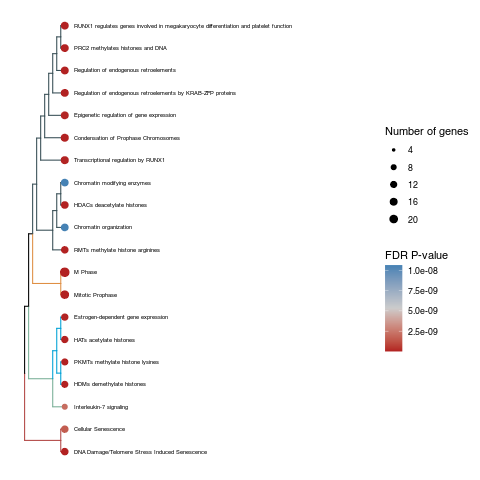

In [63]:
%%R

library(ggsci)
library(ggtree)

treeplot_custom(edo_up,
                fontsize = 2,  
                showCategory = 20, 
                hilight = F, 
                offset_tiplab = 2.2, 
                split = T,
                nWords = 0,
                label_format_cladelab = 30,
                label_format_tiplab = 90,
                label_format = 15,
                offset = 60, 
                group_color = pal_jama("default")(7)
) + 
  scale_color_gradientn(name = 'FDR P-value',
                        colours = rev(c("steelblue", "gray80", "#B22222")),   
                        guide = guide_colorbar(reverse=FALSE, 
                                               fill = guide_coloursteps(show.limits = T)))+
  scale_size_continuous(name = "Number of genes", 
                        range = c(1, 5), 
                        limits = c(4, 50), 
                        breaks = seq(4, 20, 4))

In [64]:
## Down-regulated DEGs

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


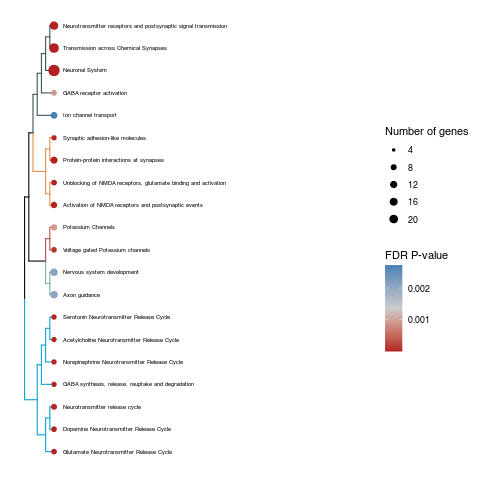

In [66]:
%%R

library(ggsci)
library(ggtree)

treeplot_custom(edo_down,
                fontsize = 2,  
                showCategory = 20, 
                hilight = F, 
                offset_tiplab = 2.2, 
                split = T,
                nWords = 0,
                label_format_cladelab = 30,
                label_format_tiplab = 90,
                label_format = 15,
                offset = 60, 
                group_color = pal_jama("default")(7)
) + 
  scale_color_gradientn(name = 'FDR P-value',
                        colours = rev(c("steelblue", "gray80", "#B22222")),   
                        guide = guide_colorbar(reverse=FALSE, 
                                               fill = guide_coloursteps(show.limits = T)))+
  scale_size_continuous(name = "Number of genes", 
                        range = c(1, 5), 
                        limits = c(4, 50), 
                        breaks = seq(4, 20, 4))

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/Figure6_reactome_Step1_KO_down_genes.pdf', dpi = 1200)

In [67]:
## Step2/Control & shSIRT6/shCtrl

In [68]:
%%R

library(enrichplot)

gene_data <- ko_s2

gene_annotations <- getBM(
  filters = "external_gene_name",
  attributes = c("entrezgene_id", "ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
  values = unique(gene_data$symbol), 
  mart = mart
)

annotated_data <- merge(
  gene_data, 
  gene_annotations, 
  by.x = 'symbol', 
  by.y = 'external_gene_name'
)

# Split into up/down regulated
upregulated <- subset(annotated_data, log2FoldChange > 0)
downregulated <- subset(annotated_data, log2FoldChange < 0)

# Pathway analysis 
pathway_analysis <- list(
  upregulated = enrichPathway(
    gene = upregulated$entrezgene_id,
    universe = as.character(back$entrezgene_id),
    organism = 'mouse',
    pvalueCutoff = 0.05,
    readable = TRUE
  ),
  
  downregulated = enrichPathway(
    gene = downregulated$entrezgene_id,
    universe = as.character(back$entrezgene_id),
    organism = 'mouse',
    pvalueCutoff = 0.05,
    readable = TRUE
  )
)

edo_up <- pairwise_termsim(pathway_analysis$upregulated)
edo_down <- pairwise_termsim(pathway_analysis$downregulated)

results <- list(
  upregulated_pathways = as.data.frame(pathway_analysis$upregulated),
  downregulated_pathways = as.data.frame(pathway_analysis$downregulated),

  edo_upregulated = as.data.frame(edo_up),
  edo_downregulated = as.data.frame(edo_down)
)

In [69]:
## Up-regulated DEGs

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


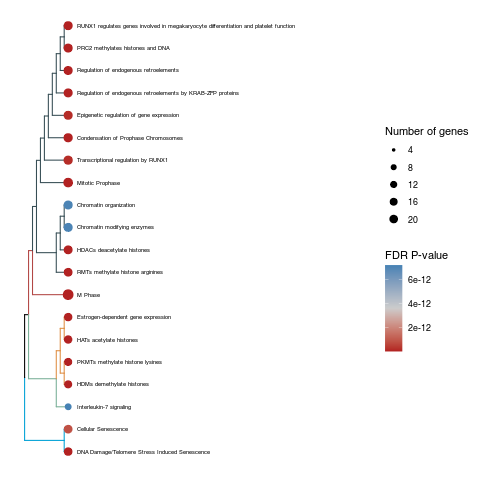

In [70]:
%%R

treeplot_custom(edo_up,
                fontsize = 2,  
                showCategory = 20, 
                hilight = F, 
                offset_tiplab = 2.2, 
                split = T,
                nWords = 0,
                label_format_cladelab = 30,
                label_format_tiplab = 90,
                label_format = 15,
                offset = 60, 
                group_color = pal_jama("default")(7)
) + 
  scale_color_gradientn(name = 'FDR P-value',
                        colours = rev(c("steelblue", "gray80", "#B22222")),   
                        guide = guide_colorbar(reverse=FALSE, 
                                               fill = guide_coloursteps(show.limits = T)))+
  scale_size_continuous(name = "Number of genes", 
                        range = c(1, 5), 
                        limits = c(4, 50), 
                        breaks = seq(4, 20, 4))

In [71]:
## Down-regulated DEGs

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


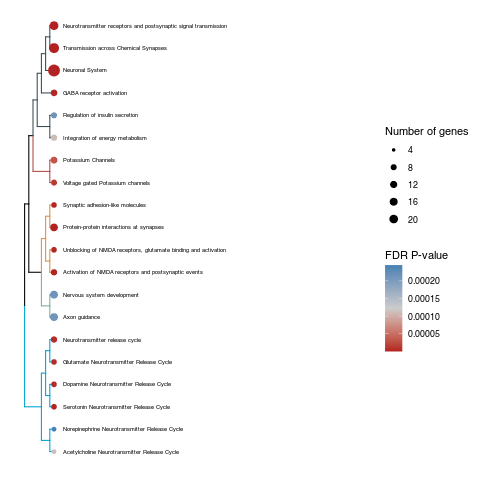

In [74]:
%%R

treeplot_custom(edo_down,
                fontsize = 2,  
                showCategory = 20, 
                hilight = F, 
                offset_tiplab = 2.2, 
                split = T,
                nWords = 0,
                label_format_cladelab = 30,
                label_format_tiplab = 90,
                label_format = 15,
                offset = 60, 
                group_color = pal_jama("default")(7)
) + 
  scale_color_gradientn(name = 'FDR P-value',
                        colours = rev(c("steelblue", "gray80", "#B22222")),   
                        guide = guide_colorbar(reverse=FALSE, 
                                               fill = guide_coloursteps(show.limits = T)))+
  scale_size_continuous(name = "Number of genes", 
                        range = c(1, 5), 
                        limits = c(4, 50), 
                        breaks = seq(4, 20, 4))

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/Figure6_reactome_Step2_KO_down_genes.pdf', dpi = 1200)

### Heatmap of log2(Fold Changes) of upregulated DEGs common between shSIRT6/shCtrl, Step1/Control and Step2/Control

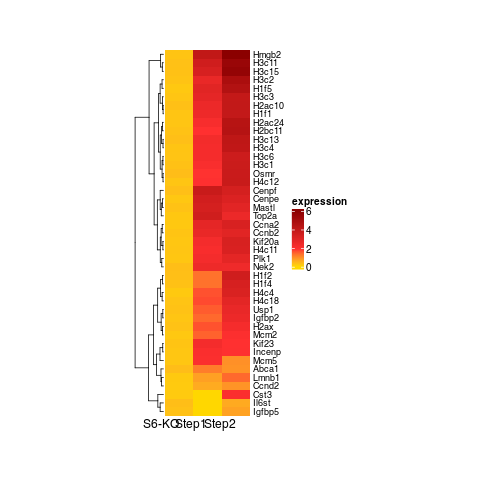

In [80]:
%%R

library(biomaRt)
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library(circlize)
library(grid) 

mart <- useEnsembl("ENSEMBL_MART_ENSEMBL",
                   dataset = "mmusculus_gene_ensembl",
                   version = 108)

# Read Reactome comparisons, extract common genes
reactome_paths <- list(
  KO_Step1 = '/tank/projects/kashuk_rnaseq/results_rnaseq/reactome_upregulated_common_DEGs_shSIRT6_Step1.csv',
  KO_Step2 = '/tank/projects/kashuk_rnaseq/results_rnaseq/reactome_upregulated_common_DEGs_shSIRT6_Step2.csv'
)

react_df <- lapply(names(reactome_paths), function(tag) {
  read.csv(reactome_paths[[tag]], stringsAsFactors = FALSE) %>%
    mutate(tag = tag,
           gene = strsplit(as.character(geneID), "/")) %>%
    unnest(gene)
}) %>% bind_rows()

# Pathways in both comparisons
common_paths <- react_df %>%
  count(Description, tag) %>%
  group_by(Description) %>%
  filter(n() == length(unique(tag))) %>%
  pull(Description)

# Genes in those pathways in both
common_genes <- react_df %>%
  filter(Description %in% common_paths) %>%
  distinct(tag, gene) %>%
  count(gene) %>%
  filter(n == length(unique(react_df$tag))) %>%
  pull(gene)

# Annotation
ann <- getBM(filters    = "external_gene_name",
             attributes = c("external_gene_name","ensembl_gene_id","description"),
             values     = common_genes,
             mart       = mart)

# Read & stack DEG tables, filtering to those Ensembl IDs
deg_paths <- list(
  `S6-KO` = '/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_shSIRT6_shCtrl.csv',
  Step1   = '/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Step1_Control.csv',
  Step2   = '/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Step2_Control.csv'
)

df_long <- bind_rows(lapply(names(deg_paths), function(lbl) {
  read.csv(deg_paths[[lbl]],
           sep = ifelse(grepl("\\.csv$", deg_paths[[lbl]]), ",", ";"),
           stringsAsFactors = FALSE) %>%
    filter(gene %in% ann$ensembl_gene_id) %>%
    transmute(
      gene_id = symbol,
      log2fc  = log2FoldChange,
      type    = lbl
    )
})) %>%
  mutate(type = factor(type, levels = c("S6-KO", "Step1", "Step2")))

df_wide <- df_long %>%
  arrange(gene_id) %>%
  pivot_wider(names_from = type, values_from = log2fc) 

df_wide <- as.data.frame(df_wide)
rownames(df_wide) <- df_wide$gene_id
df_wide$gene_id <- NULL  

mat = as.matrix(df_wide)
mat_scaled = t(apply(mat, 1, scale))

base_mean = rowMeans(mat)
type = gsub("s\\d+_", "", colnames(mat))

col_fun <- colorRamp2(
  c(0, median(df_long$log2fc), max(df_long$log2fc)),
  c("gold", "firebrick1", "red4")
)

row_space <- unit(0.3, "cm")  
col_space <- unit(1, "cm")  

Heatmap(
  mat, 
  name = "expression",
  col = col_fun,
  column_names_rot = 0,
  show_row_names = TRUE,
  column_order = c("S6-KO", "Step1", "Step2"),
  row_names_gp = gpar(fontsize = 9), 
  row_labels = rownames(mat),  
  row_title_gp = gpar(fontsize = 8),
  width = ncol(mat) * col_space,
  height = nrow(mat) * row_space
)

### Summary line‐plot of mean log2FC per condition

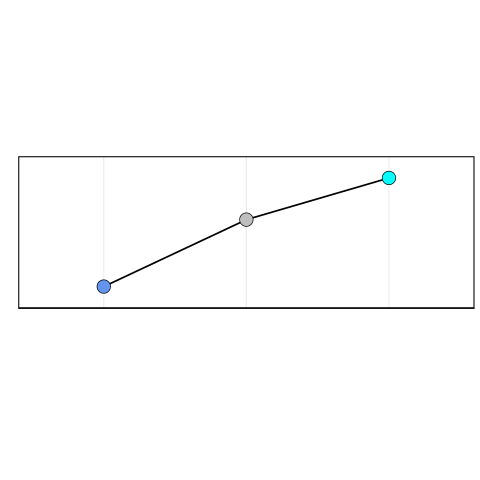

In [83]:
%%R

df_wide2 <- df_long %>% pivot_wider(names_from = type, values_from = log2fc)

# Compute means
value <- colMeans(df_wide2[ , c("S6-KO","Step1","Step2")] )
type  <- c("KO","Step1","Step2")
data  <- data.frame(value, type)

ggplot(data, aes(x = type, y = value)) +
  geom_line(aes(group = 1), size = 0.8, color = "black") +
  geom_point(aes(fill = type), size = 6, shape = 21, color = "black") +
  xlab("") + ylab("") +
  theme_minimal() +
  theme(
    axis.text.y   = element_text(colour = "black", size = 12),
    axis.text.x   = element_blank(),
    axis.line     = element_line(colour = "black"),
    panel.border  = element_rect(colour = "black", fill = NA, size = 1),
    legend.position = "none",
    aspect.ratio  = 1/3
  ) +
  scale_fill_manual(values = c('cornflowerblue','grey','cyan')) +
  scale_y_discrete(expand = expansion(0.2))

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/Figure6_lineplot_meanlogFC.pdf', dpi=1200)